# Digital Finance, Forecasting & Analytics Platform
## Module 3 - IFRS Reporting Automation & Anomaly Detection (Python + SQLAlchemy + Pandas)
### 3.2 - Data Loading and Validation (Python + SQLAlchemy + Pandas)

This module supports the IFRS Data Warehouse integration in Python by loading the core fact tables and financial statement views used across the FP&A workflow. In the project context, the full anomaly detection logic was already developed in Module 3.1; therefore, this notebook is intentionally lighter and focused on database connection, structured extraction, and a simple sanity check to confirm that the main datasets are available and consistent for downstream analysis and reporting.

### Setup & Imports

In [1]:
import os
import logging
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

SCHEMA = "finance_ifrs_dw"
SCENARIO_KEY = 1

print("Libraries loaded.")

Libraries loaded.


### Logging configuration

In [2]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger(__name__)

logger.info("Logging configured.")

11:18:27 [INFO] Logging configured.


### 1- Database Connection

In [3]:
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT", "5432")
DB_NAME = os.getenv("DB_NAME")

DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(DATABASE_URL)

try:
    with engine.connect() as conn:
        conn.execute(text("SELECT 1"))
    print("Database connection established successfully.")
except SQLAlchemyError as e:
    logger.error(f"Database connection failed: {e}")
    raise

Database connection established successfully.


### 2- Data Extraction

#### Facts

In [4]:
FACT_TABLES = [
    "fact_sales",
    "fact_cogs",
    "fact_opex",
    "fact_depreciation",
    "fact_assets",
    "fact_debt",
    "fact_equity",
    "fact_taxes",
    "fact_workingcapital",
    "fact_cashflow",
    "fact_price_volume"
]

def extract_fact(fact_name: str) -> pd.DataFrame:
    query = f"""
        SELECT d.MonthYear, f.*
        FROM {SCHEMA}.{fact_name} f
        JOIN {SCHEMA}.dim_date d ON f.DateKey = d.DateKey
        WHERE f.scenariokey = {SCENARIO_KEY}
        ORDER BY d.MonthYear
    """
    df = pd.read_sql(query, engine).round(2)
    for col in ["datekey", "DateKey"]:
        if col in df.columns:
            df.rename(columns={col: "datekey"}, inplace=True)
            df["datekey"] = pd.to_numeric(df["datekey"], errors="coerce").astype("Int64")
            df["date"] = pd.to_datetime(df["datekey"].astype(str), format="%Y%m", errors="coerce")
            break
    return df

facts = {}
print("Extracting fact tables (scenariokey=1)...")
for name in FACT_TABLES:
    try:
        facts[name] = extract_fact(name)
        print(f"  {name:22s}: {facts[name].shape[0]:5d} rows x {facts[name].shape[1]:2d} cols")
    except SQLAlchemyError as e:
        logger.error(f"Failed to load {name}: {e}")
        facts[name] = pd.DataFrame()

print(f"\nAll {len([f for f in facts.values() if not f.empty])} fact tables extracted.")

Extracting fact tables (scenariokey=1)...
  fact_sales            :  1620 rows x  9 cols
  fact_cogs             :   540 rows x  8 cols
  fact_opex             :  1260 rows x  8 cols
  fact_depreciation     :   180 rows x  7 cols
  fact_assets           :  1080 rows x  7 cols
  fact_debt             :   720 rows x  7 cols
  fact_equity           :   540 rows x  7 cols
  fact_taxes            :   360 rows x  7 cols
  fact_workingcapital   :   540 rows x  7 cols
  fact_cashflow         :  1620 rows x  7 cols
  fact_price_volume     :  1620 rows x  8 cols

All 11 fact tables extracted.


#### Views

In [5]:
view_queries = {
    "P&L": f"SELECT * FROM {SCHEMA}.vw_pl_annual_pivot ORDER BY account",
    "P&L_m": f"SELECT * FROM {SCHEMA}.vw_pl_monthly ORDER BY datekey",
    "Balance_Sheet": f"SELECT * FROM {SCHEMA}.vw_bs_annual_pivot ORDER BY account",
    "Cash_Flow": f"SELECT * FROM {SCHEMA}.vw_cf_annual_pivot ORDER BY account"
}

dfs_views = {}
for name, query in view_queries.items():
    try:
        df = pd.read_sql(query, engine).round(2)

        if "datekey" in df.columns:
            df["datekey"] = pd.to_numeric(df["datekey"], errors="coerce").astype("Int64")
            df["date"] = pd.to_datetime(df["datekey"].astype(str), format="%Y%m", errors="coerce")

        dfs_views[name] = df

        if "date" in df.columns and df["date"].notna().any():
            date_range = f"{df['date'].min().strftime('%Y-%m')} -> {df['date'].max().strftime('%Y-%m')}"
        else:
            date_range = "n/a"

        print(
            f"  {name:14s}: {df.shape[0]:4d} rows x {df.shape[1]:2d} cols | range: {date_range}"
        )

    except SQLAlchemyError as e:
        logger.error(f"Failed to load view {name}: {e}")
        dfs_views[name] = pd.DataFrame()

df_pl = dfs_views["P&L"]
df_plm = dfs_views["P&L_m"]
df_bs = dfs_views["Balance_Sheet"]
df_cf = dfs_views["Cash_Flow"]

print("\nLoaded view columns:")
print("P&L        :", list(df_pl.columns))
print("P&L Monthly:", list(df_plm.columns))
print("Balance    :", list(df_bs.columns))
print("Cash Flow  :", list(df_cf.columns))

  P&L           :   10 rows x 18 cols | range: n/a
  P&L_m         :  180 rows x 19 cols | range: 2010-01 -> 2024-12
  Balance_Sheet :   19 rows x 18 cols | range: n/a
  Cash_Flow     :    8 rows x 18 cols | range: n/a

Loaded view columns:
P&L        : ['accountkey', 'account', 'ifrs_reference', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
P&L Monthly: ['datekey', 'year', 'month', 'revenue', 'cogs', 'COGS (%)', 'gross_profit', 'Gross (%)', 'opex', 'Opex (%)', 'ebitda', 'EBITDA (%)', 'depreciation', 'financial_results', 'ebt', 'totaltaxes', 'net_income', 'Net Margin (%)', 'date']
Balance    : ['accountkey', 'account', 'ifrs_reference', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']
Cash Flow  : ['accountkey', 'account', 'ifrs_reference', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', 

### 3- Simple Sanity Check

In [6]:
def simple_check(df: pd.DataFrame, source_name: str) -> dict:
    result = {
        "source": source_name,
        "rows": len(df),
        "cols": len(df.columns),
        "nulls": int(df.isna().sum().sum()) if not df.empty else 0,
        "duplicates": int(df.duplicated().sum()) if not df.empty else 0,
        "status": "OK"
    }

    if df.empty:
        result["status"] = "EMPTY"
    elif result["duplicates"] > 0 or result["nulls"] > 0:
        result["status"] = "CHECK"

    return result

check_results = []

for name, df in facts.items():
    check_results.append(simple_check(df, f"fact:{name}"))

for name, df in dfs_views.items():
    check_results.append(simple_check(df, f"view:{name}"))

df_check = pd.DataFrame(check_results)
df_check

,source,rows,cols,nulls,duplicates,status
0,fact:fact_sales,1620,9,0,0,OK
1,fact:fact_cogs,540,8,0,0,OK
2,fact:fact_opex,1260,8,0,0,OK
3,fact:fact_depreciation,180,7,0,0,OK
4,fact:fact_assets,1080,7,0,0,OK
5,fact:fact_debt,720,7,0,0,OK
6,fact:fact_equity,540,7,0,0,OK
7,fact:fact_taxes,360,7,0,0,OK
8,fact:fact_workingcapital,540,7,0,0,OK
9,fact:fact_cashflow,1620,7,0,0,OK


### 4- Data Transformation, Calculations & Report Generation

In [7]:
### P&L - Margins Calculations
# Transformation, Calculations & Report Generation

pl = df_pl.copy()
pl = pl.drop(columns=['accountkey', 'ifrs_reference']) 
pl = pl.set_index('account') 
pl.loc['Gross_%'] = round(pl.loc['GrossProfit'] / pl.loc['Revenue'],4)*100
pl.loc['EBITDA_%'] = round(pl.loc['EBITDA'] / pl.loc['Revenue'],4)*100
pl.loc['EBT_%'] = round(pl.loc['EBT'] / pl.loc['Revenue'],4)*100
pl.loc['Net_%'] = round(pl.loc['NetIncome'] / pl.loc['Revenue'],4)*100

order = [
    'Revenue',
    'CostOfGoodsSold',
    'GrossProfit',
    'Gross_%',
    'OperatingExpenses',
    'EBITDA',
    'EBITDA_%',
    'DepreciationExpense',
    'FinancialResults',
    'EBT',
    'EBT_%',
    'TotalTaxes',
    'NetIncome',
    'Net_%'
]

pl = pl.loc[order]
pl.to_csv("py_files_cvs/p&l_annual.csv")
pl

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
account,,,,,,,,,,,,,,,
Revenue,"15,900.98","17,013.21","17,858.23","18,902.32","20,197.53","21,773.67","23,005.13","23,832.73","23,995.61","23,379.50","24,615.46","26,330.82","29,104.67","30,726.94","32,114.33"
CostOfGoodsSold,"8,057.91","8,775.87","9,328.84","9,633.80","10,066.90","10,988.69","11,879.65","12,421.20","12,672.00","12,132.96","12,447.55","13,145.43","14,870.47","15,918.60","16,343.06"
GrossProfit,"7,843.07","8,237.34","8,529.39","9,268.52","10,130.63","10,784.98","11,125.48","11,411.53","11,323.61","11,246.54","12,167.91","13,185.39","14,234.20","14,808.34","15,771.27"
Gross_%,49.32,48.42,47.76,49.03,50.16,49.53,48.36,47.88,47.19,48.10,49.43,50.08,48.91,48.19,49.11
OperatingExpenses,"3,657.21","3,742.92","3,928.81","4,158.51","4,645.43","5,443.41","5,751.28","6,911.49","9,118.33","9,585.58","7,138.47","7,109.32","7,276.17","6,759.93","7,386.29"
EBITDA,"4,185.86","4,494.42","4,600.58","5,110.01","5,485.20","5,341.57","5,374.20","4,500.04","2,205.28","1,660.96","5,029.44","6,076.07","6,958.03","8,048.41","8,384.98"
EBITDA_%,26.32,26.42,25.76,27.03,27.16,24.53,23.36,18.88,9.19,7.10,20.43,23.08,23.91,26.19,26.11
DepreciationExpense,800.00,856.00,914.73,977.66,"1,042.31","1,110.14","1,182.91","1,262.47","1,345.51","1,390.40","1,375.15","1,414.77","1,498.51","1,589.27","1,741.54"
FinancialResults,-359.56,-368.10,-364.68,-361.05,-356.96,-354.18,-350.83,-355.57,-373.05,-437.72,-484.72,-355.08,-347.13,-336.08,-336.18


In [8]:
### P&L Monthly
# Transformation, Calculations & Report Generation

plm = df_plm.copy()
plm = plm.drop(columns=[
    'year',
    'month',
    'COGS (%)',
    'Gross (%)',
    'Opex (%)',
    'EBITDA (%)',
    'Net Margin (%)'
])
plm.to_csv("py_files_cvs/p&l_monthly.csv")
plm

,datekey,revenue,cogs,gross_profit,opex,ebitda,depreciation,financial_results,ebt,totaltaxes,net_income,date
0,201001,954.07,483.47,470.60,304.79,165.81,66.67,-29.96,69.18,75.66,-6.48,2010-01-01
1,201002,"1,033.57",523.77,509.80,304.79,205.01,66.67,-29.96,108.38,75.66,32.72,2010-02-01
2,201003,"1,351.59",684.93,666.66,304.79,361.87,66.67,-29.96,265.24,75.66,189.58,2010-03-01
3,201004,"1,272.08",644.63,627.45,304.79,322.66,66.67,-29.96,226.03,75.66,150.37,2010-04-01
4,201005,"1,431.08",725.22,705.86,304.79,401.07,66.67,-29.96,304.44,75.66,228.78,2010-05-01
...,...,...,...,...,...,...,...,...,...,...,...,...
175,202408,"1,695.65",862.91,832.74,615.51,217.23,145.13,-28.01,44.09,157.68,-113.59,2024-08-01
176,202409,"3,661.04","1,863.11","1,797.93",615.51,"1,182.42",145.13,-28.01,"1,009.28",157.68,851.60,2024-09-01
177,202410,"3,214.65","1,635.94","1,578.71",615.51,963.20,145.13,-28.01,790.06,157.68,632.38,2024-10-01
178,202411,"3,294.93","1,676.79","1,618.14",615.51,"1,002.63",145.13,-28.01,829.49,157.68,671.81,2024-11-01


In [9]:
### Balance Sheet Statement
# Transformation, Calculations & Report Generation

bs = df_bs.copy()
bs = bs.drop(columns=['accountkey', 'ifrs_reference']) 
bs = bs.set_index('account') 
bs.loc['BalanceCheck'] = round(bs.loc['TotalAssets'] - bs.loc['TotalLiabilities'] - bs.loc['TotalEquity'],2)*100
bs.to_csv("py_files_cvs/balance_annual.csv")
bs

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
account,,,,,,,,,,,,,,,
AccountsPayable,"3,062.01","3,334.83","3,358.38","2,986.48","3,221.41","3,626.27","3,801.49","4,099.00","4,308.48","4,246.54","4,232.17","4,469.45","5,055.96","5,093.95","5,229.78"
AccountsReceivable,"3,600.00","3,816.24","3,913.04","4,107.39","4,536.56","5,049.38","5,661.15","6,441.44","7,149.82","7,678.60","6,546.26","6,892.33","6,846.01","6,985.12","7,067.20"
Capital,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
Cash,467.80,675.01,871.18,"1,071.87","1,098.36","1,235.77",630.42,0.00,0.00,0.00,279.36,629.85,"1,476.45","1,243.54","1,127.95"
CurrentAssets,"6,485.17","7,124.01","7,489.58","7,587.71","8,352.98","9,142.21","9,617.87","10,043.59","10,951.42","11,803.81","10,310.93","10,939.99","11,891.37","11,889.94","11,790.62"
CurrentLiabilities,"3,062.01","3,334.83","3,358.38","2,986.48","3,221.41","3,626.27","3,801.49","4,289.65","5,560.68","6,314.82","4,232.17","4,469.45","5,055.96","5,093.95","5,229.78"
DeferredTaxes,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,50.15,0.00,0.00,0.00,0.00
Dividends,"1,059.21","1,144.61","1,162.41","1,319.96","1,430.08","1,357.04","1,344.16","1,008.70",136.28,0.00,"1,134.43","1,507.18","1,968.27","2,357.38","2,649.05"
IntangibleAssets,"1,607.00","1,721.34","1,843.55","1,973.84","2,112.61","2,260.47","2,418.28","2,586.47","2,760.27","2,932.16","3,109.01","3,296.32","3,494.98","3,712.67","3,949.82"


In [10]:
### Cash Flow Statement
# Transformation, Calculations & Report Generation

cf = df_cf.copy()
cf = cf.drop(columns=['accountkey', 'ifrs_reference']) 
cf = cf.set_index('account') 
cf.to_csv("py_files_cvs/cashflow_annual.csv")
cf

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
account,,,,,,,,,,,,,,,
CashEnd,467.80,675.01,871.18,"1,071.87","1,098.36","1,235.77",630.42,0.00,0.00,0.00,279.36,629.85,"1,476.45","1,243.54","1,127.95"
CFF,"-1,695.25","-1,189.10","-1,196.21","-1,361.72","-1,481.89","-1,420.09","-1,393.42",-851.15,"1,109.41","2,092.92","-1,183.87","-1,575.79","-2,079.23","-2,422.27","-2,704.54"
CFI,"-1,500.00","-1,590.10","-1,701.32","-1,785.82","-1,890.23","-2,019.75","-2,177.37","-2,300.51","-1,906.62","-1,199.78","-1,870.36","-2,461.55","-2,633.08","-3,492.56","-3,687.23"
CFO,"2,163.05","2,986.41","3,093.70","3,348.23","3,398.61","3,577.25","2,965.44","2,521.24",987.86,359.06,"5,401.87","4,387.83","5,558.91","5,681.92","6,276.18"
DeltaAP,62.01,272.82,23.55,-371.90,234.93,404.86,175.22,297.51,209.48,-61.94,-14.37,237.28,586.51,37.99,135.83
DeltaAR,-400.00,-216.24,-96.80,-194.35,-429.17,-512.82,-611.77,-780.29,-708.38,-528.78,"1,132.34",-346.07,46.32,-139.11,-82.08
DeltaDebt,-636.04,-44.49,-33.80,-41.76,-51.81,-63.05,-49.26,-33.10,-6.51,24.64,-49.44,-68.61,-110.96,-64.89,-55.49
DeltaInventory,-417.37,-215.39,-72.60,296.91,-309.61,-139.00,-469.24,-275.85,-199.45,-323.61,639.90,67.50,-151.10,-92.37,65.81


In [11]:
### Fact depreciation, Fact assets, Fact debt, Fact equity, Fact taxes, Fact cashflow, Fact workingcapital
# Transformation, Calculations & Report Generation

os.makedirs("py_files_cvs", exist_ok=True)

fact_transform_specs = {
    "fact_depreciation": {
        "output": "py_files_cvs/depreciation.csv",
        "mode": "depreciation"
    },
    "fact_assets": {
        "output": "py_files_cvs/assets.csv",
        "mode": "pivot"
    },
    "fact_debt": {
        "output": "py_files_cvs/debt.csv",
        "mode": "pivot"
    },
    "fact_equity": {
        "output": "py_files_cvs/equity.csv",
        "mode": "pivot"
    },
    "fact_taxes": {
        "output": "py_files_cvs/taxes.csv",
        "mode": "pivot"
    },
    "fact_cashflow": {
        "output": "py_files_cvs/cashflow.csv",
        "mode": "pivot"
    },
    "fact_workingcapital": {
        "output": "py_files_cvs/workingcapital.csv",
        "mode": "pivot"
    }
}

transformed_facts = {}

for fact_name, spec in fact_transform_specs.items():
    df_fact = facts[fact_name].copy()

    if "scenariokey" in df_fact.columns:
        df_fact = df_fact[df_fact["scenariokey"] == SCENARIO_KEY]

    if spec["mode"] == "depreciation":
        df_fact = df_fact.drop(columns=[
            c for c in ["monthyear", "accountkey", "accountname"] if c in df_fact.columns
        ])
        if "amount" in df_fact.columns:
            df_fact = df_fact.rename(columns={"amount": "DepreciationExpense"})

    elif spec["mode"] == "pivot":
        if "monthyear" in df_fact.columns:
            df_fact = df_fact.drop(columns="monthyear")
        df_fact = df_fact.pivot(index="datekey", columns="accountname", values="amount")

    df_fact.to_csv(spec["output"])
    transformed_facts[fact_name] = df_fact
    print(f"Saved: {spec['output']}")

depreciation = transformed_facts["fact_depreciation"]
assets = transformed_facts["fact_assets"]
debt = transformed_facts["fact_debt"]
equity = transformed_facts["fact_equity"]
taxes = transformed_facts["fact_taxes"]
cashflow = transformed_facts["fact_cashflow"]
workingcapital = transformed_facts["fact_workingcapital"]

Saved: py_files_cvs/depreciation.csv
Saved: py_files_cvs/assets.csv
Saved: py_files_cvs/debt.csv
Saved: py_files_cvs/equity.csv
Saved: py_files_cvs/taxes.csv
Saved: py_files_cvs/cashflow.csv
Saved: py_files_cvs/workingcapital.csv


In [12]:
### Fact cogs
# Transformation, Calculations & Report Generation

cogs = facts["fact_cogs"].copy()
cogs = cogs[cogs["scenariokey"] == SCENARIO_KEY]

product_names = {1: "Ind", 2: "Aut", 3: "Elec"}
cogs["product"] = cogs["productkey"].map(product_names)

cogs.drop(columns=[c for c in ["monthyear", "productkey"] if c in cogs.columns], inplace=True)
cogs = (
    cogs.pivot_table(
        index="datekey",
        columns="product",
        values="amount",
        aggfunc="sum",
        margins=True,
        margins_name="cogs"
    )
    .reset_index()
)

cogs.to_csv("py_files_cvs/cogs.csv")
cogs

product,datekey,Aut,Elec,Ind,cogs
0,201001,188.81,106.56,188.10,483.47
1,201002,204.55,115.44,203.78,523.77
2,201003,267.49,150.96,266.48,684.93
3,201004,251.75,142.08,250.80,644.63
4,201005,283.22,159.84,282.16,725.22
...,...,...,...,...,...
176,202409,644.33,490.89,727.89,"1,863.11"
177,202410,565.76,431.04,639.14,"1,635.94"
178,202411,579.89,441.80,655.10,"1,676.79"
179,202412,519.98,396.16,587.42,"1,503.56"


In [13]:
### Fact opex
# Transformation, Calculations & Report Generation

opex = facts["fact_opex"].copy()
opex = opex[opex["scenariokey"] == SCENARIO_KEY]

businessunit_names = {
    1: "Production",
    2: "R&D",
    3: "Sales",
    4: "Marketing",
    5: "Logistics",
    6: "Administration",
    7: "FixedCosts"
}

opex["businessunit"] = opex["businessunitkey"].map(businessunit_names)

opex.drop(columns=[c for c in ["monthyear", "businessunitkey"] if c in opex.columns], inplace=True)
opex = (
    opex.pivot_table(
        index="datekey",
        columns="businessunit",
        values="amount",
        aggfunc="sum",
        margins=True,
        margins_name="opex"
    )
    .reset_index()
)

opex.to_csv("py_files_cvs/opex.csv")
opex

businessunit,datekey,Administration,FixedCosts,Logistics,Marketing,Production,R&D,Sales,opex
0,201001,30.48,61.11,42.52,48.92,82.44,24.23,15.09,304.79
1,201002,30.48,61.11,42.52,48.92,82.44,24.23,15.09,304.79
2,201003,30.48,61.11,42.52,48.92,82.44,24.23,15.09,304.79
3,201004,30.48,61.11,42.52,48.92,82.44,24.23,15.09,304.79
4,201005,30.48,61.11,42.52,48.92,82.44,24.23,15.09,304.79
...,...,...,...,...,...,...,...,...,...
176,202409,64.63,91.71,87.40,101.56,174.19,59.09,36.93,615.51
177,202410,64.63,91.71,87.40,101.56,174.19,59.09,36.93,615.51
178,202411,64.63,91.71,87.40,101.56,174.19,59.09,36.93,615.51
179,202412,64.63,91.75,87.45,101.58,174.23,59.09,36.95,615.68


In [14]:
### Fact Price_Volume
# Transformation, Calculations & Report Generation

price_volume = facts["fact_price_volume"].copy()
price_volume = price_volume[price_volume["scenariokey"] == SCENARIO_KEY]

channel_names = {1: "Direct", 2: "Retail", 3: "Online"}
product_names = {1: "Industrial", 2: "Automotive", 3: "Electric"}

price_volume["channel"] = price_volume["channelkey"].map(channel_names)
price_volume["product"] = price_volume["productkey"].map(product_names)
price_volume.drop(columns=[
    c for c in ["monthyear", "channelkey", "productkey", "scenariokey"] if c in price_volume.columns
], inplace=True)

price_volume = price_volume[["datekey", "channel", "product", "price", "units"]]
price_volume.to_csv("py_files_cvs/price_volume.csv")

price_volume

,datekey,channel,product,price,units
0,201001,Direct,Industrial,"1,616.00",147.00
1,201001,Direct,Automotive,591.60,265.00
2,201001,Direct,Electric,"1,224.00",7.00
3,201001,Retail,Industrial,"1,858.40",53.00
4,201001,Retail,Automotive,709.92,309.00
...,...,...,...,...,...
1615,202412,Retail,Automotive,"1,077.05",285.00
1616,202412,Retail,Electric,"2,290.12",160.00
1617,202412,Online,Industrial,"2,550.88",56.00
1618,202412,Online,Automotive,987.29,237.00


In [15]:
### Fact Sales
# Transformation, Calculations & Report Generation

sales = facts["fact_sales"].copy()
sales = sales[sales["scenariokey"] == SCENARIO_KEY]

channel_names = {1: "Direct", 2: "Retail", 3: "Online"}
product_names = {1: "Industrial", 2: "Automotive", 3: "Electric"}

sales["channel"] = sales["channelkey"].map(channel_names)
sales["product"] = sales["productkey"].map(product_names)

sales = sales.drop(columns=[
    c for c in ["monthyear", "channelkey", "productkey", "accountkey", "accountname"] if c in sales.columns
])

sales.to_csv("py_files_cvs/sales.csv")
sales

,datekey,amount,scenariokey,date,channel,product
0,201001,237.07,1,2010-01-01,Direct,Industrial
1,201001,156.68,1,2010-01-01,Direct,Automotive
2,201001,8.01,1,2010-01-01,Direct,Electric
3,201001,99.24,1,2010-01-01,Retail,Industrial
4,201001,219.32,1,2010-01-01,Retail,Automotive
...,...,...,...,...,...,...
1615,202412,307.47,1,2024-12-01,Retail,Automotive
1616,202412,364.07,1,2024-12-01,Retail,Electric
1617,202412,142.69,1,2024-12-01,Online,Industrial
1618,202412,234.89,1,2024-12-01,Online,Automotive


In [16]:
### Fact Sales for Visualization

tbl = (
    sales
    .groupby(["datekey", "channel", "product"])["amount"]
    .sum()
    .unstack(["channel", "product"])
)

tot_prod = tbl.T.groupby(level="product").sum().T
tot_chan = tbl.T.groupby(level="channel").sum().T
sales_all = pd.concat([tbl, tot_prod, tot_chan], axis=1)
sales_all["Revenue"] = sales_all[["Direct", "Retail", "Online"]].sum(axis=1)

sales_all.columns = [
    "_".join([str(c) for c in col if c]).strip() if isinstance(col, tuple) else col
    for col in sales_all.columns
]

sales_all.loc["Revenue"] = sales_all.sum()
sales_all.to_csv("py_files_cvs/sales_all.csv")

sales_base = (
    sales
    .reset_index()
    .groupby(["datekey", "channel", "product"], as_index=False)
    .agg(amount_sum=("amount", "sum"))
)

sales_by_channel = (
    sales_base
    .groupby(["datekey", "channel"], as_index=False)["amount_sum"]
    .sum()
    .pivot(index="datekey", columns="channel", values="amount_sum")
    .rename_axis(None, axis=1)
).reset_index()

sales_by_product = (
    sales_base
    .groupby(["datekey", "product"], as_index=False)["amount_sum"]
    .sum()
    .pivot(index="datekey", columns="product", values="amount_sum")
    .rename_axis(None, axis=1)
).reset_index()

sales_all

,Direct_Automotive,Direct_Electric,Direct_Industrial,Online_Automotive,Online_Electric,Online_Industrial,Retail_Automotive,Retail_Electric,Retail_Industrial,Automotive,Electric,Industrial,Direct,Online,Retail,Revenue
datekey,,,,,,,,,,,,,,,,
201001,156.68,8.01,237.07,9.33,15.06,5.70,219.32,203.66,99.24,385.33,226.73,342.01,401.76,30.09,522.22,954.07
201002,169.74,8.67,256.82,10.11,16.31,6.18,237.60,220.63,107.51,417.45,245.61,370.51,435.23,32.60,565.74,"1,033.57"
201003,221.96,11.34,335.85,13.22,21.33,8.08,310.71,288.51,140.59,545.89,321.18,484.52,569.15,42.63,739.81,"1,351.59"
201004,208.91,10.67,316.09,12.44,20.08,7.60,292.43,271.54,132.32,513.78,302.29,456.01,535.67,40.12,696.29,"1,272.08"
201005,235.02,12.01,355.60,14.00,22.58,8.55,328.98,305.48,148.86,578.00,340.07,513.01,602.63,45.13,783.32,"1,431.08"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202409,634.89,66.93,969.06,291.06,519.76,176.81,381.00,451.14,170.39,"1,306.95","1,037.83","1,316.26","1,670.88",987.63,"1,002.53","3,661.04"
202410,557.48,58.77,850.90,255.57,456.39,155.25,334.54,396.13,149.62,"1,147.59",911.29,"1,155.77","1,467.15",867.21,880.29,"3,214.65"
202411,571.40,60.24,872.15,261.95,467.78,159.13,342.90,406.02,153.36,"1,176.25",934.04,"1,184.64","1,503.79",888.86,902.28,"3,294.93"


### 5 - Visualization

In [17]:
# Set Seaborn theme
sns.set_style("darkgrid")
palette = sns.color_palette("deep")

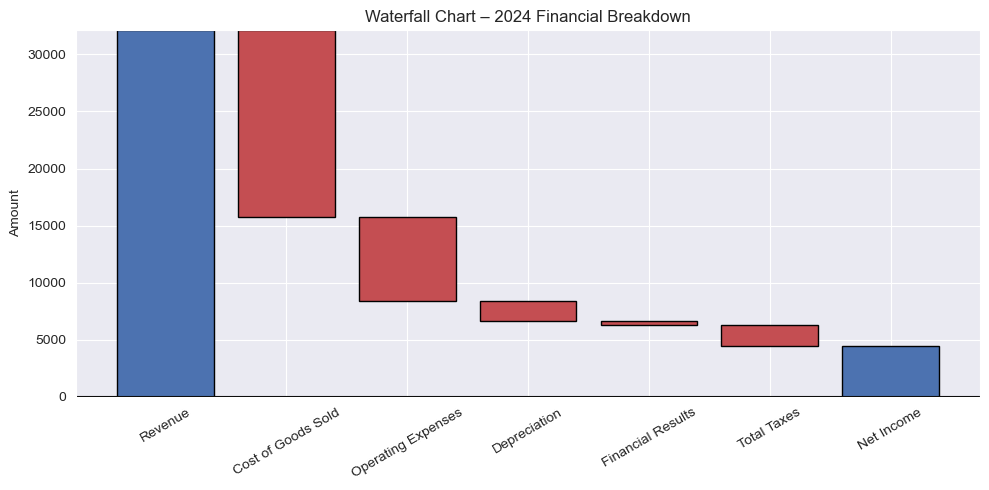

In [18]:
### Visualization 1: Waterfall Chart – 2024 Financial Breakdown
blue, red = palette[0], palette[3]

labels = [
    "Revenue", "Cost of Goods Sold", "Operating Expenses",
    "Depreciation", "Financial Results", "Total Taxes", "Net Income"
]

vals = [
    pl.loc["Revenue", "2024"],
    -pl.loc["CostOfGoodsSold", "2024"],
    -pl.loc["OperatingExpenses", "2024"],
    -pl.loc["DepreciationExpense", "2024"],
    pl.loc["FinancialResults", "2024"],
    -pl.loc["TotalTaxes", "2024"]
]

# Net Income is the amount required to close the chart at zero
net_income_final = -sum(vals)

vals.append(net_income_final)

# colors
colors = [blue if v >= 0 else red for v in vals]
# Force Net Income color to blue
colors[-1] = blue

# cumulative bottoms
cum = [0] + list(np.cumsum(vals[:-1]))

fig, ax = plt.subplots(figsize=(10,5))

for lbl, v, c, col in zip(labels, vals, cum, colors):
    ax.bar(lbl, v, bottom=c, color=col, edgecolor="black")

ax.axhline(0, color="black")
ax.set_title("Waterfall Chart – 2024 Financial Breakdown")
ax.set_ylabel("Amount")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

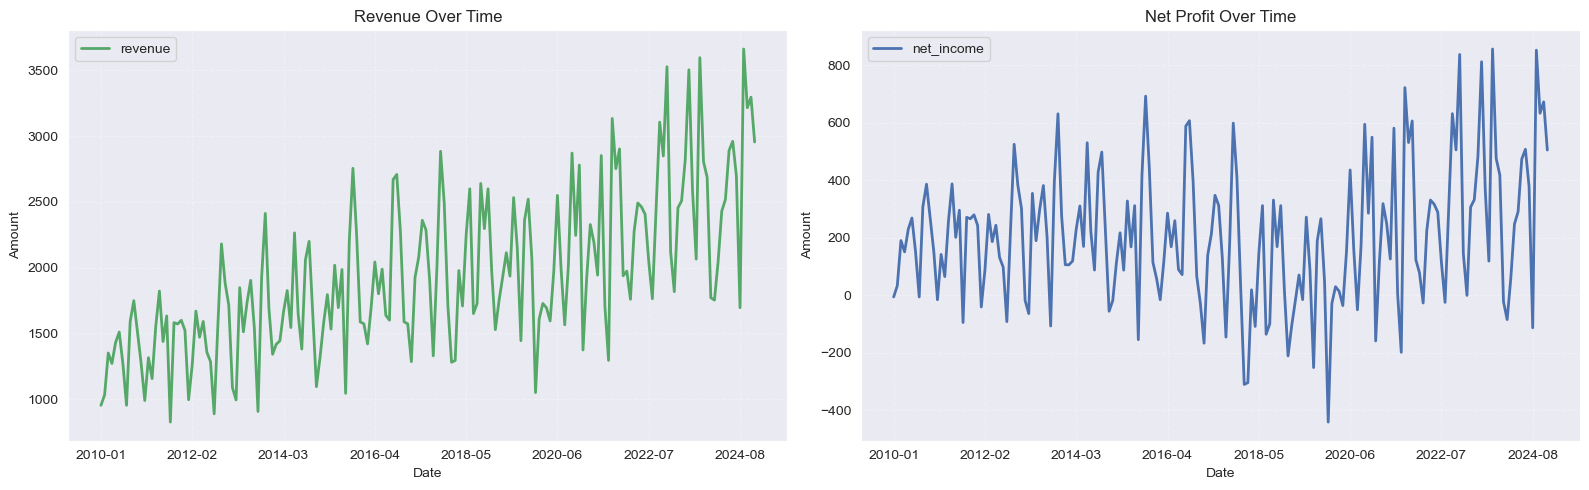

In [19]:
### Visualization 2: Revenue and Profit Over Time

# Seaborn style and palette
sns.set_style("darkgrid")
palette = sns.color_palette("deep")

blue = palette[0]   # azul seaborn
green = palette[2]  # verde seaborn

# Prepare Data
plm_plot = plm.copy()
plm_plot["datekey"] = pd.to_datetime(plm_plot["datekey"], format="%Y%m")
plm_plot["datekey"] = plm_plot["datekey"].dt.strftime("%Y-%m")

# Create figure with two side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---------- Revenue Plot ----------
plm_plot.plot(
    x="datekey",
    y="revenue",
    kind="line",
    ax=axes[0],
    linewidth=2,
    color=green,
    title="Revenue Over Time"
)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Amount")
axes[0].grid(True, linestyle="--", alpha=0.3)

# ---------- Net Profit Plot ----------
plm_plot.plot(
    x="datekey",
    y="net_income",
    kind="line",
    ax=axes[1],
    linewidth=2,
    color=blue,
    title="Net Profit Over Time"
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Amount")
axes[1].grid(True, linestyle="--", alpha=0.3)

# Final layout adjustment
plt.tight_layout()
plt.show()

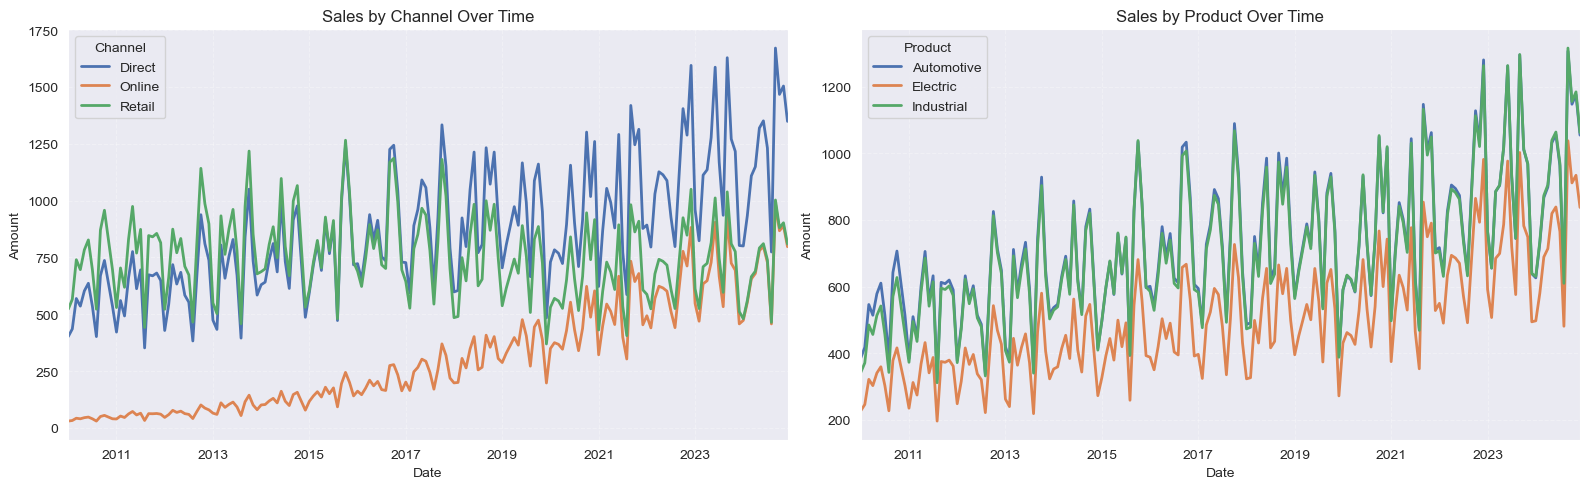

In [20]:
### Visualization 3: Sales by Channel Over Time and Sales by Product Over Time

# --- Plot Side by Side ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sales_by_channel["datekey"] = pd.to_datetime(sales_by_channel["datekey"], format="%Y%m")
sales_by_product["datekey"]  = pd.to_datetime(sales_by_product["datekey"], format="%Y%m")

# ------------ Sales by Channel ------------
sales_by_channel.plot(
    x="datekey",
    kind="line",
    ax=axes[0],
    linewidth=2,
    color=palette,
    title="Sales by Channel Over Time"
)

axes[0].set_xlabel("Date")
axes[0].set_ylabel("Amount")
axes[0].grid(True, linestyle="--", alpha=0.3)
axes[0].legend(title="Channel", loc="best")

# ------------ Sales by Product ------------
sales_by_product.plot(
    x="datekey",
    kind="line",
    ax=axes[1],
    linewidth=2,
    color=palette,
    title="Sales by Product Over Time"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Amount")
axes[1].grid(True, linestyle="--", alpha=0.3)
axes[1].legend(title="Product", loc="best")

plt.tight_layout()
plt.show()

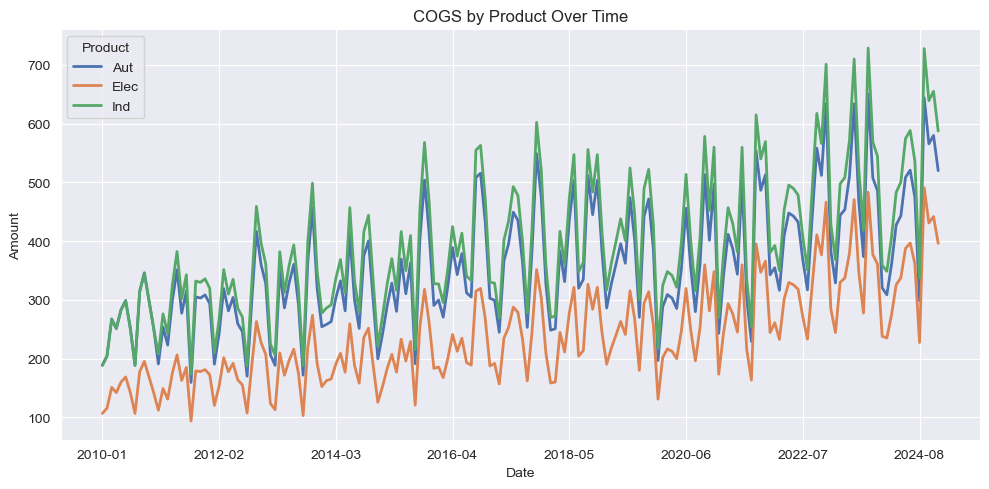

In [21]:
### Visualization 4: COGS by Product Over Time
# COGS by Product
cogs_plt = cogs.drop(columns= "cogs")
cogs_plt = cogs_plt.drop(cogs_plt.index[-1]) 
cogs_plt["datekey"] = pd.to_datetime(cogs_plt["datekey"], format="%Y%m")
cogs_plt["datekey"] = cogs_plt["datekey"].dt.strftime("%Y-%m")

cogs_plt.plot(
    x="datekey",
    kind="line",
    figsize=(10, 5),
    color=palette,
    linewidth=2,
    title="COGS by Product Over Time"
)
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend(title="Product", loc="best")
plt.tight_layout()
plt.show()


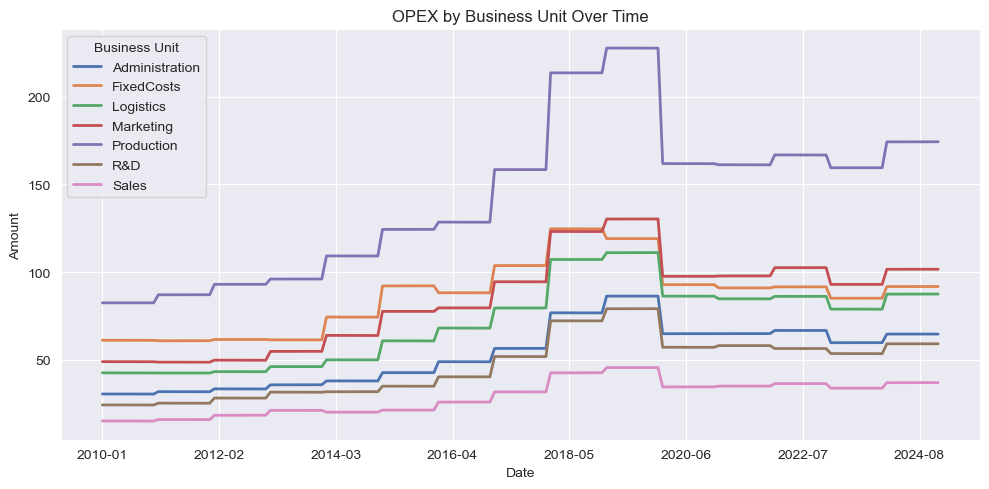

In [22]:
### Visualization 5: OPEX by Business Unit Over Time
opex_plt = opex.drop(columns= "opex")
opex_plt = opex_plt.drop(opex_plt.index[-1]) 
opex_plt["datekey"] = pd.to_datetime(opex_plt["datekey"], format="%Y%m")
opex_plt["datekey"] = opex_plt["datekey"].dt.strftime("%Y-%m")

# OPEX by Business Unit ---
opex_plt.plot(
    x="datekey",
    kind="line",
    figsize=(10, 5),
    color=palette,
    linewidth=2,
    title="OPEX by Business Unit Over Time"
)
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend(title="Business Unit", loc="best")
plt.tight_layout()
plt.show()

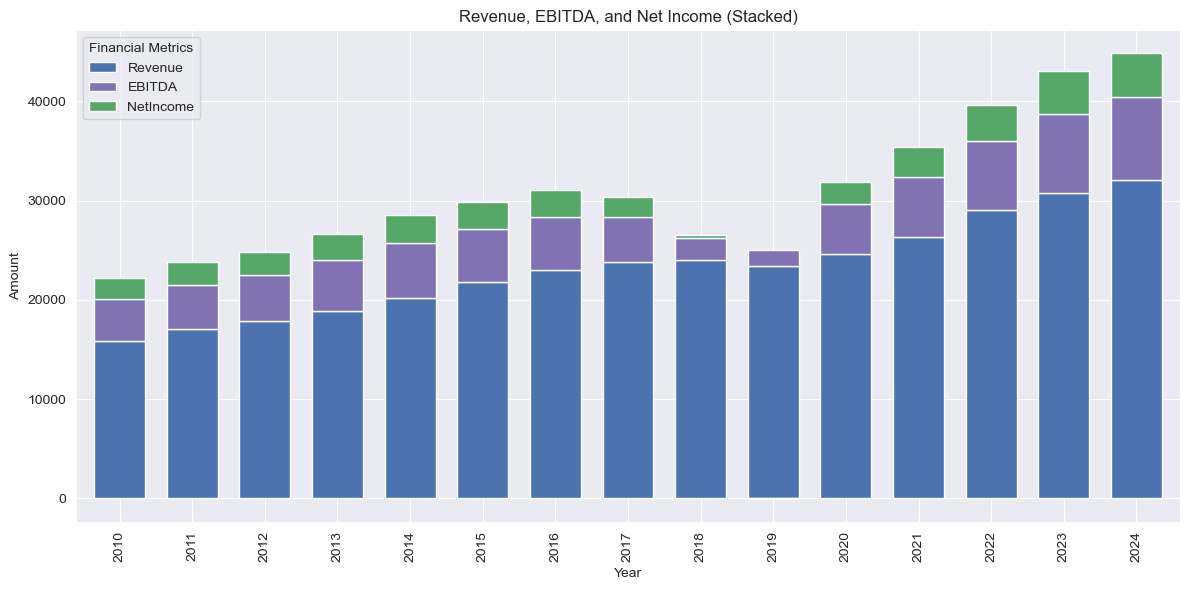

In [23]:
### Visualization 6: Stacked Bar Chart – Revenue, EBITDA, and Net Income

colors = [palette[0], palette[4], palette[2]]

pl_plot = pl.loc[["Revenue", "EBITDA", "NetIncome"]].T

ax = pl_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=colors,
    width=0.7,
    title="Revenue, EBITDA, and Net Income (Stacked)"
)

plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend(title="Financial Metrics", loc="best")
plt.tight_layout()
plt.show()

### 5- IFRS Financial Indicators

5.1 Liquidity Ratios

In [24]:
# Liquidity Ratios
liquidity = pd.DataFrame(index=bs.columns)

# Current Ratio = Current Assets / Current Liabilities
liquidity["Current_Ratio"] = (bs.loc["CurrentAssets"] / bs.loc["CurrentLiabilities"]).round(2)

# Quick Ratio = (Current Assets - Inventory) / Current Liabilities
liquidity["Quick_Ratio"] = ((bs.loc["CurrentAssets"] - bs.loc["Inventory"]) / bs.loc["CurrentLiabilities"]).round(2)

5.2 Leverage and Capital Structure

In [25]:
# Leverage and Capital Structure
leverage = pd.DataFrame(index=bs.columns)

# Net Debt = Total Debt (Revolving + Noncurrent Liabilities) - Cash
leverage["Net_Debt"] = (bs.loc["RevolvingCredit"] + bs.loc["NonCurrentLiabilities"] - bs.loc["Cash"]).round(2)

# Net Debt / EBITDA
leverage["Net_Debt_EBITDA"] = (leverage["Net_Debt"] / pl.loc["EBITDA"]).round(2)

# Debt to Equity = Total Debt / Total Equity
leverage["Debt_to_Equity"] = ((bs.loc["RevolvingCredit"] + bs.loc["NonCurrentLiabilities"]) / bs.loc["TotalEquity"]).round(2)

# Debt to Assets = Total Debt / Total Assets
leverage["Debt_to_Assets"] = ((bs.loc["RevolvingCredit"] + bs.loc["NonCurrentLiabilities"]) / bs.loc["TotalAssets"]).round(2)

# Interest Coverage = EBIT / |Financial Results|
leverage["Interest_Coverage"] = ((pl.loc["EBITDA"] - pl.loc["DepreciationExpense"]) / abs(pl.loc["FinancialResults"])).round(2)

5.3 Profitability Ratios

In [26]:
profit = pd.DataFrame(index=pl.columns)

# ROE = Net Income / Total Equity
profit["ROE (%)"] = ((pl.loc["NetIncome"] / bs.loc["TotalEquity"]) * 100).round(2)

# ROA = Net Income / Total Assets
profit["ROA (%)"] = ((pl.loc["NetIncome"] / bs.loc["TotalAssets"]) * 100).round(2)

# Gross Margin = Gross Profit / Revenue
profit["Gross Margin (%)"] = ((pl.loc["GrossProfit"] / pl.loc["Revenue"]) * 100).round(2)

# EBITDA Margin = EBITDA / Revenue
profit["EBITDA Margin (%)"] = ((pl.loc["EBITDA"] / pl.loc["Revenue"]) * 100).round(2)

# Net Margin = Net Income / Revenue
profit["Net Margin (%)"] = ((pl.loc["NetIncome"] / pl.loc["Revenue"]) * 100).round(2)

5.4 Efficiency Ratios

In [27]:
efficiency = pd.DataFrame(index=bs.columns)

# Asset Turnover = Revenue / Total Assets
efficiency["Asset Turnover"] = (pl.loc["Revenue"] / bs.loc["TotalAssets"]).round(2)

# Days Sales Outstanding (DSO) = (Accounts Receivable / Revenue) * 365
efficiency["Days Sales Outstanding (DSO)"] = ((bs.loc["AccountsReceivable"] / pl.loc["Revenue"]) * 365).round(2)

# Days Payable Outstanding (DPO) = (Accounts Payable / COGS) * 365
efficiency["Days Payable Outstanding (DPO)"] = ((bs.loc["AccountsPayable"] / pl.loc["CostOfGoodsSold"]) * 365).round(2)

# Days Inventory Outstanding (DIO) = (Inventory / COGS) * 365
efficiency["Days Inventory Outstanding (DIO)"] = ((bs.loc["Inventory"] / pl.loc["CostOfGoodsSold"]) * 365).round(2)

5.5 Cash Flow Indicators

In [28]:
cash = pd.DataFrame(index=cf.columns)

# Operating Cash Flow (CFO)
cash["CFO"] = cf.loc["CFO"].round(2)

# Free Cash Flow (FCF) = CFO + CFI (CFI normalmente é negativo)
cash["FCF"] = (cf.loc["CFO"] + cf.loc["CFI"]).round(2)

# CFO / Net Income Ratio
cash["CFO / Net Income"] = (cf.loc["CFO"] / pl.loc["NetIncome"]).round(2)

# FCF / Net Income Ratio
cash["FCF / Net Income"] = (cash["FCF"] / pl.loc["NetIncome"]).round(2)

# CFO / Total Assets (Cash Flow on Assets)
cash["CFO / Assets"] = (cf.loc["CFO"] / bs.loc["TotalAssets"]).round(2)

In [29]:
## 5.6 Consolidated IFRS Indicators Report
indicators = pd.concat([
    liquidity.T,
    leverage.T,
    profit.T,
    efficiency.T,
    cash.T
], axis=0)

# Display the summary
indicators

,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Current_Ratio,2.12,2.14,2.23,2.54,2.59,2.52,2.53,2.34,1.97,1.87,2.44,2.45,2.35,2.33,2.25
Quick_Ratio,1.33,1.35,1.42,1.73,1.75,1.73,1.66,1.50,1.29,1.22,1.61,1.68,1.65,1.62,1.57
Net_Debt,"8,896.16","8,644.46","8,414.49","8,172.04","8,093.74","7,893.28","8,449.37","9,237.34","10,292.38","11,133.10","8,736.02","8,316.92","7,359.36","7,527.38","7,587.48"
Net_Debt_EBITDA,2.13,1.92,1.83,1.60,1.48,1.48,1.57,2.05,4.67,6.70,1.74,1.37,1.06,0.94,0.90
Debt_to_Equity,0.78,0.71,0.65,0.59,0.54,0.49,0.46,0.44,0.49,0.53,0.41,0.38,0.35,0.32,0.30
Debt_to_Assets,0.38,0.36,0.34,0.33,0.31,0.29,0.28,0.27,0.29,0.31,0.26,0.24,0.23,0.21,0.20
Interest_Coverage,9.42,9.88,10.11,11.45,12.45,11.95,11.95,9.11,2.30,0.62,7.54,13.13,15.73,19.22,19.76
ROE (%),17.57,17.34,16.18,16.83,16.71,14.69,13.57,9.69,1.62,-0.56,10.29,12.80,14.22,15.82,15.30
ROA (%),8.65,8.85,8.61,9.46,9.69,8.69,8.22,5.91,0.96,-0.32,6.43,8.15,9.16,10.46,10.31
Gross Margin (%),49.32,48.42,47.76,49.03,50.16,49.53,48.36,47.88,47.19,48.10,49.43,50.08,48.91,48.19,49.11


In [30]:
indicators_t = indicators.T.reset_index().rename(columns={"index": "Year"})
#indicators_t.to_csv("py_files_cvs/ifrs_financial_indicators_t.csv")
#indicators_t.to_excel("py_files_cvs/ifrs_financial_indicators_t.xlsx")
indicators_t 

,Year,Current_Ratio,Quick_Ratio,Net_Debt,Net_Debt_EBITDA,Debt_to_Equity,Debt_to_Assets,Interest_Coverage,ROE (%),ROA (%),Gross Margin (%),EBITDA Margin (%),Net Margin (%),Asset Turnover,Days Sales Outstanding (DSO),Days Payable Outstanding (DPO),Days Inventory Outstanding (DIO),CFO,FCF,CFO / Net Income,FCF / Net Income,CFO / Assets
0,2010,2.12,1.33,"8,896.16",2.13,0.78,0.38,9.42,17.57,8.65,49.32,26.32,13.32,0.65,82.64,138.70,109.50,"2,163.05",663.05,1.02,0.31,0.09
1,2011,2.14,1.35,"8,644.46",1.92,0.71,0.36,9.88,17.34,8.85,48.42,26.42,13.46,0.66,81.87,138.70,109.50,"2,986.41","1,396.31",1.30,0.61,0.12
2,2012,2.23,1.42,"8,414.49",1.83,0.65,0.34,10.11,16.18,8.61,47.76,25.76,13.02,0.66,79.98,131.40,105.85,"3,093.70","1,392.38",1.33,0.60,0.11
3,2013,2.54,1.73,"8,172.04",1.60,0.59,0.33,11.45,16.83,9.46,49.03,27.03,13.97,0.68,79.31,113.15,91.25,"3,348.23","1,562.41",1.27,0.59,0.12
4,2014,2.59,1.75,"8,093.74",1.48,0.54,0.31,12.45,16.71,9.69,50.16,27.16,14.16,0.68,81.98,116.80,98.55,"3,398.61","1,508.38",1.19,0.53,0.12
5,2015,2.52,1.73,"7,893.28",1.48,0.49,0.29,11.95,14.69,8.69,49.53,24.53,12.46,0.70,84.64,120.45,94.90,"3,577.25","1,557.50",1.32,0.57,0.11
6,2016,2.53,1.66,"8,449.37",1.57,0.46,0.28,11.95,13.57,8.22,48.36,23.36,11.69,0.70,89.82,116.80,102.20,"2,965.44",788.07,1.10,0.29,0.09
7,2017,2.34,1.50,"9,237.34",2.05,0.44,0.27,9.11,9.69,5.91,47.88,18.88,8.46,0.70,98.65,120.45,105.85,"2,521.24",220.73,1.25,0.11,0.07
8,2018,1.97,1.29,"10,292.38",4.67,0.49,0.29,2.30,1.62,0.96,47.19,9.19,1.42,0.67,108.76,124.10,109.50,987.86,-918.76,2.90,-2.70,0.03
9,2019,1.87,1.22,"11,133.10",6.70,0.53,0.31,0.62,-0.56,-0.32,48.10,7.10,-0.50,0.64,119.88,127.75,124.10,359.06,-840.72,-3.07,7.19,0.01


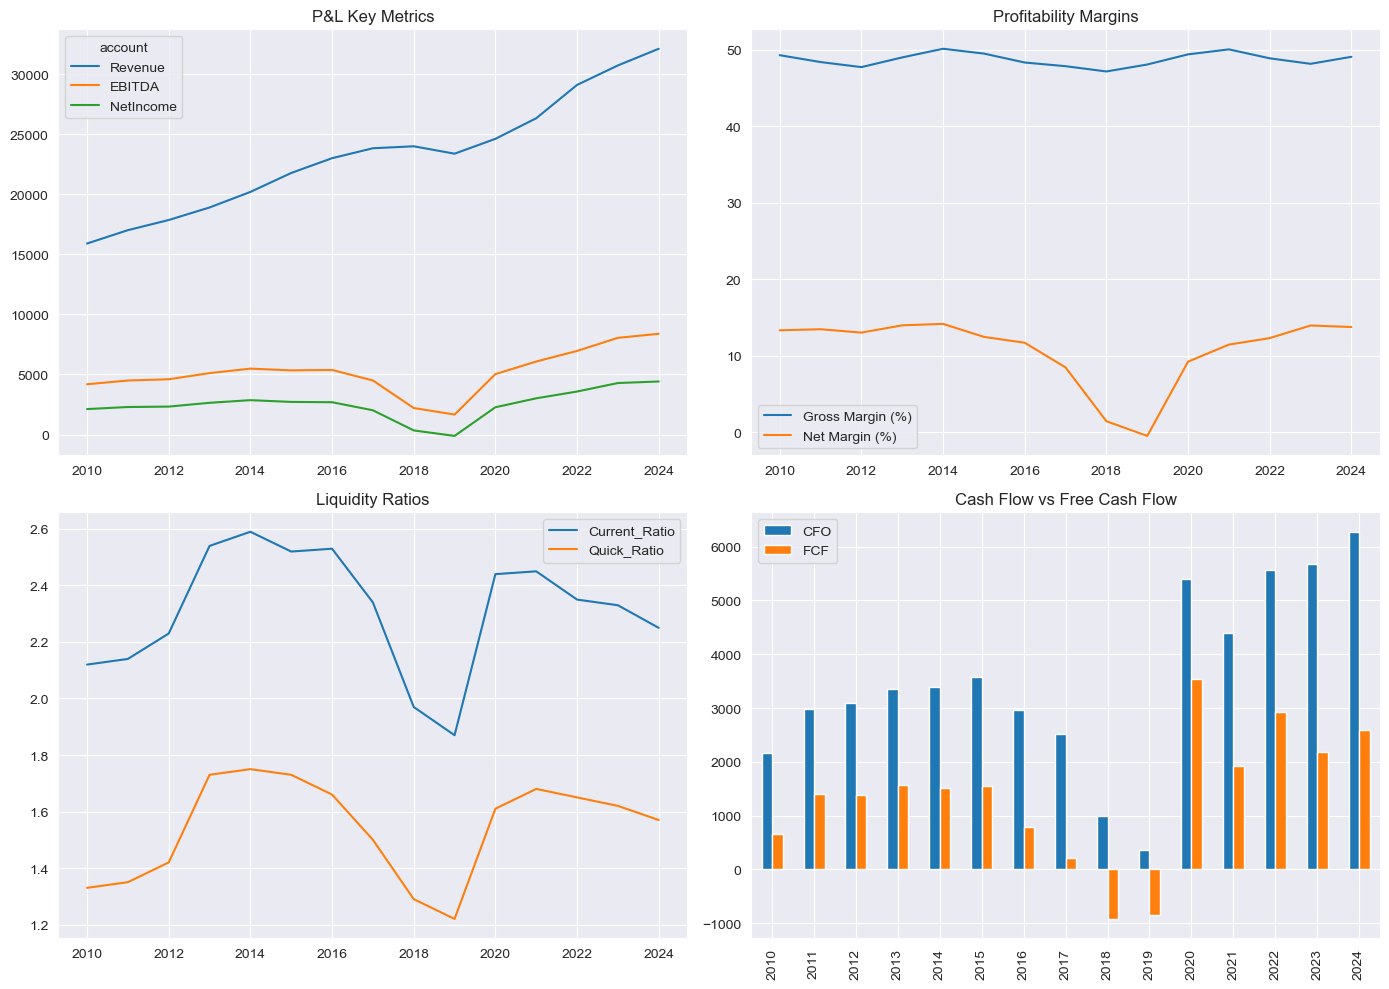

In [31]:
### Visualization 7: Consolidated Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14,10))
pl.loc[["Revenue", "EBITDA", "NetIncome"]].T.plot(ax=axes[0,0], title="P&L Key Metrics")
profit[["Gross Margin (%)","Net Margin (%)"]].plot(ax=axes[0,1], title="Profitability Margins")
liquidity[["Current_Ratio","Quick_Ratio"]].plot(ax=axes[1,0], title="Liquidity Ratios")
cash[["CFO","FCF"]].plot(ax=axes[1,1], kind="bar", title="Cash Flow vs Free Cash Flow")
plt.tight_layout()
plt.show()

## IFRS Financial Indicators - 2024 vs Industry Benchmark

| Indicator | Company 2024 | Industry Benchmark | Analysis |
|------------|--------------|--------------------|-----------|
| **Current Ratio** | 2.25 | 1.3 - 1.8 | Well above the industry norm, indicating strong short-term liquidity and a comfortable working capital position. |
| **Quick Ratio** | 1.57 | 0.8 - 1.2 | Above peers, showing strong liquidity even without relying heavily on inventory conversion. |
| **Net Debt / EBITDA** | 0.90x | 1.0x - 2.5x | Below the typical leverage range, signaling low financial risk and good debt capacity. |
| **Debt to Equity** | 0.30x | 0.5x - 1.0x | Capital structure remains conservative, with leverage below the sector average. |
| **Debt to Assets** | 0.20x | 0.40 - 0.60 | Low leverage supports balance-sheet resilience, although it may also indicate modest use of debt financing. |
| **Interest Coverage** | 19.76x | > 5x | Very strong debt-servicing capacity, supported by healthy operating earnings. |
| **ROE (Return on Equity)** | 15.30% | 10% - 18% | Within a strong benchmark range, indicating solid returns to shareholders. |
| **ROA (Return on Assets)** | 10.31% | 5% - 10% | Slightly above the benchmark ceiling, reflecting efficient asset utilization. |
| **Gross Margin (%)** | 49.11% | 30% - 40% | Clearly above industry levels, suggesting strong pricing power and a favorable cost structure. |
| **EBITDA Margin (%)** | 26.11% | 15% - 25% | Slightly above the peer range, pointing to strong operating efficiency. |
| **Net Margin (%)** | 13.75% | 6% - 12% | Above benchmark, showing robust profitability after financial expenses and taxes. |
| **Asset Turnover** | 0.75x | 0.8x - 1.5x | Slightly below benchmark, indicating some room to improve asset productivity. |
| **Days Sales Outstanding (DSO)** | 80.32 days | 40 - 60 days | Higher than benchmark, which may indicate slower receivables collection than peers. |
| **Days Payable Outstanding (DPO)** | 116.80 days | 45 - 75 days | Well above industry norms, supporting working capital but potentially reflecting long supplier payment cycles. |
| **Days Inventory Outstanding (DIO)** | 80.30 days | 60 - 90 days | Within the expected range, indicating balanced inventory management. |
| **Operating Cash Flow (CFO)** | 6,276.18 | Positive and growing | Strong operating cash generation reinforces liquidity and investment capacity. |
| **Free Cash Flow (FCF)** | 2,588.95 | Positive, >5% of revenue | Positive free cash flow supports reinvestment, deleveraging, and strategic flexibility. |
| **CFO / Net Income** | 1.42x | ~1.0x | Strong cash conversion, suggesting good earnings quality. |

---

### Summary Analysis

The company shows a **very strong liquidity and solvency profile** in 2024, with low leverage, high interest coverage, and ratios comfortably above standard safety thresholds.  
Profitability remains **above industry benchmarks**, especially in gross margin, EBITDA margin, and net margin, reinforcing the view of solid operating performance.  
The main watchpoint is **working capital efficiency**, particularly the higher DSO and very extended DPO, while cash generation remains strong with **CFO / Net Income at 1.42x**.

### Regression Files

In [32]:
rev = sales_all[["Revenue"]]
rev = rev.iloc[:-1]
rev = rev.reset_index()  

rev

,datekey,Revenue
0,201001,954.07
1,201002,"1,033.57"
2,201003,"1,351.59"
3,201004,"1,272.08"
4,201005,"1,431.08"
...,...,...
175,202408,"1,695.65"
176,202409,"3,661.04"
177,202410,"3,214.65"
178,202411,"3,294.93"


In [33]:
### Marketing Files
mkt = opex[["datekey", "Marketing"]]
mkt = mkt.iloc[:-1]

mkt

businessunit,datekey,Marketing
0,201001,48.92
1,201002,48.92
2,201003,48.92
3,201004,48.92
4,201005,48.92
...,...,...
175,202408,101.56
176,202409,101.56
177,202410,101.56
178,202411,101.56


In [34]:
reg = price_volume
channel_map = {"Direct": "D", "Retail": "R", "Online": "O"}
reg["channel"] = reg["channel"].map(channel_map)

product_map = {"Industrial": "I", "Automotive": "A", "Electric": "E"}
reg["product"] = reg["product"].map(product_map)
reg

,datekey,channel,product,price,units
0,201001,D,I,"1,616.00",147.00
1,201001,D,A,591.60,265.00
2,201001,D,E,"1,224.00",7.00
3,201001,R,I,"1,858.40",53.00
4,201001,R,A,709.92,309.00
...,...,...,...,...,...
1615,202412,R,A,"1,077.05",285.00
1616,202412,R,E,"2,290.12",160.00
1617,202412,O,I,"2,550.88",56.00
1618,202412,O,A,987.29,237.00


In [35]:
### Price Volume – Aggregation and Pivot
reg = price_volume
reg

tbl_reg = (
    reg
    .groupby(["datekey", "channel", "product"])[["price", "units"]]
    .sum()
    .unstack(["channel", "product"])
)

tbl_reg.columns = ["_".join(col).strip() for col in tbl_reg.columns.to_flat_index()]

tbl_reg = tbl_reg.reset_index()

#tbl_reg.to_csv(r"C:\Users\gusta\Meu Drive (gustavo.provento@gmail.com)\GitHub\Finance\Module_4\tbl_reg.csv", index=False)
#tbl_reg.to_excel(r"C:\Users\gusta\Meu Drive (gustavo.provento@gmail.com)\GitHub\Finance\Module_4\tbl_reg.xlsx", index=False)

#tbl_reg.to_excel("py_files_cvs/tbl_price_volume.xlsx")
tbl_reg

,datekey,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,price_R_E,price_R_I,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I
0,201001,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",265.00,7.00,147.00,14.00,12.00,3.00,309.00,151.00,53.00
1,201002,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",287.00,7.00,159.00,16.00,13.00,4.00,335.00,164.00,58.00
2,201003,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",375.00,9.00,208.00,20.00,17.00,5.00,438.00,214.00,76.00
3,201004,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",353.00,9.00,196.00,19.00,16.00,4.00,412.00,202.00,71.00
4,201005,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",397.00,10.00,220.00,22.00,18.00,5.00,463.00,227.00,80.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,202408,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",328.00,15.00,185.00,137.00,113.00,32.00,164.00,91.00,28.00
176,202409,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",707.00,32.00,399.00,295.00,245.00,69.00,354.00,197.00,61.00
177,202410,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",621.00,28.00,350.00,259.00,215.00,61.00,311.00,173.00,54.00
178,202411,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",637.00,29.00,359.00,265.00,220.00,62.00,318.00,177.00,55.00


In [36]:
reg = (
    rev
    .merge(mkt, on="datekey", how="left")
    .merge(tbl_reg, on="datekey", how="left")
)

#reg.to_csv(r"C:\Users\gusta\Meu Drive (gustavo.provento@gmail.com)\GitHub\Finance\Module_4\reg.csv", index=False)
#reg.to_excel(r"C:\Users\gusta\Meu Drive (gustavo.provento@gmail.com)\GitHub\Finance\Module_4\reg.xlsx", index=False)

reg

,datekey,Revenue,Marketing,price_D_A,price_D_E,price_D_I,price_O_A,price_O_E,price_O_I,price_R_A,price_R_E,price_R_I,units_D_A,units_D_E,units_D_I,units_O_A,units_O_E,units_O_I,units_R_A,units_R_E,units_R_I
0,201001,954.07,48.92,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",265.00,7.00,147.00,14.00,12.00,3.00,309.00,151.00,53.00
1,201002,"1,033.57",48.92,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",287.00,7.00,159.00,16.00,13.00,4.00,335.00,164.00,58.00
2,201003,"1,351.59",48.92,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",375.00,9.00,208.00,20.00,17.00,5.00,438.00,214.00,76.00
3,201004,"1,272.08",48.92,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",353.00,9.00,196.00,19.00,16.00,4.00,412.00,202.00,71.00
4,201005,"1,431.08",48.92,591.60,"1,224.00","1,616.00",650.76,"1,248.48","1,696.80",709.92,"1,346.40","1,858.40",397.00,10.00,220.00,22.00,18.00,5.00,463.00,227.00,80.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,202408,"1,695.65",101.56,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",328.00,15.00,185.00,137.00,113.00,32.00,164.00,91.00,28.00
176,202409,"3,661.04",101.56,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",707.00,32.00,399.00,295.00,245.00,69.00,354.00,197.00,61.00
177,202410,"3,214.65",101.56,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",621.00,28.00,350.00,259.00,215.00,61.00,311.00,173.00,54.00
178,202411,"3,294.93",101.56,897.54,"2,081.93","2,429.41",987.29,"2,123.57","2,550.88","1,077.05","2,290.12","2,793.82",637.00,29.00,359.00,265.00,220.00,62.00,318.00,177.00,55.00
